<a href="https://colab.research.google.com/github/Anikk02/Tesla-Stock-Price-Forecasting/blob/main/Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OBJECTIVE**

This analysis aims to understand and forecast Tesla's stock price behavior using time series decomposition. By examining long-term trends, weekly patterns, yearly seasonality, and daily fluctuations, the goal is to identify key temporal dynamics influencing stock performance. This insight will support more accurate forecasting, strategic investment decisions, and deeper understanding of cyclical behaviors in Tesla's market activity.

APPROACH:
  Prepare the dataset (ds, y), fit Prophet to model trend and seasonality, generate forecasts with confidence intervals, and validate accuracy using error metrics for reliable future insights.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Import pystan and Prophet
!pip install pystan
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.0 MB/s eta 0:00:00


In [ ]:
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
data = pd.read_csv('TSLA.csv')
data.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


In [ ]:
data.shape

(2956, 7)

In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [ ]:
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


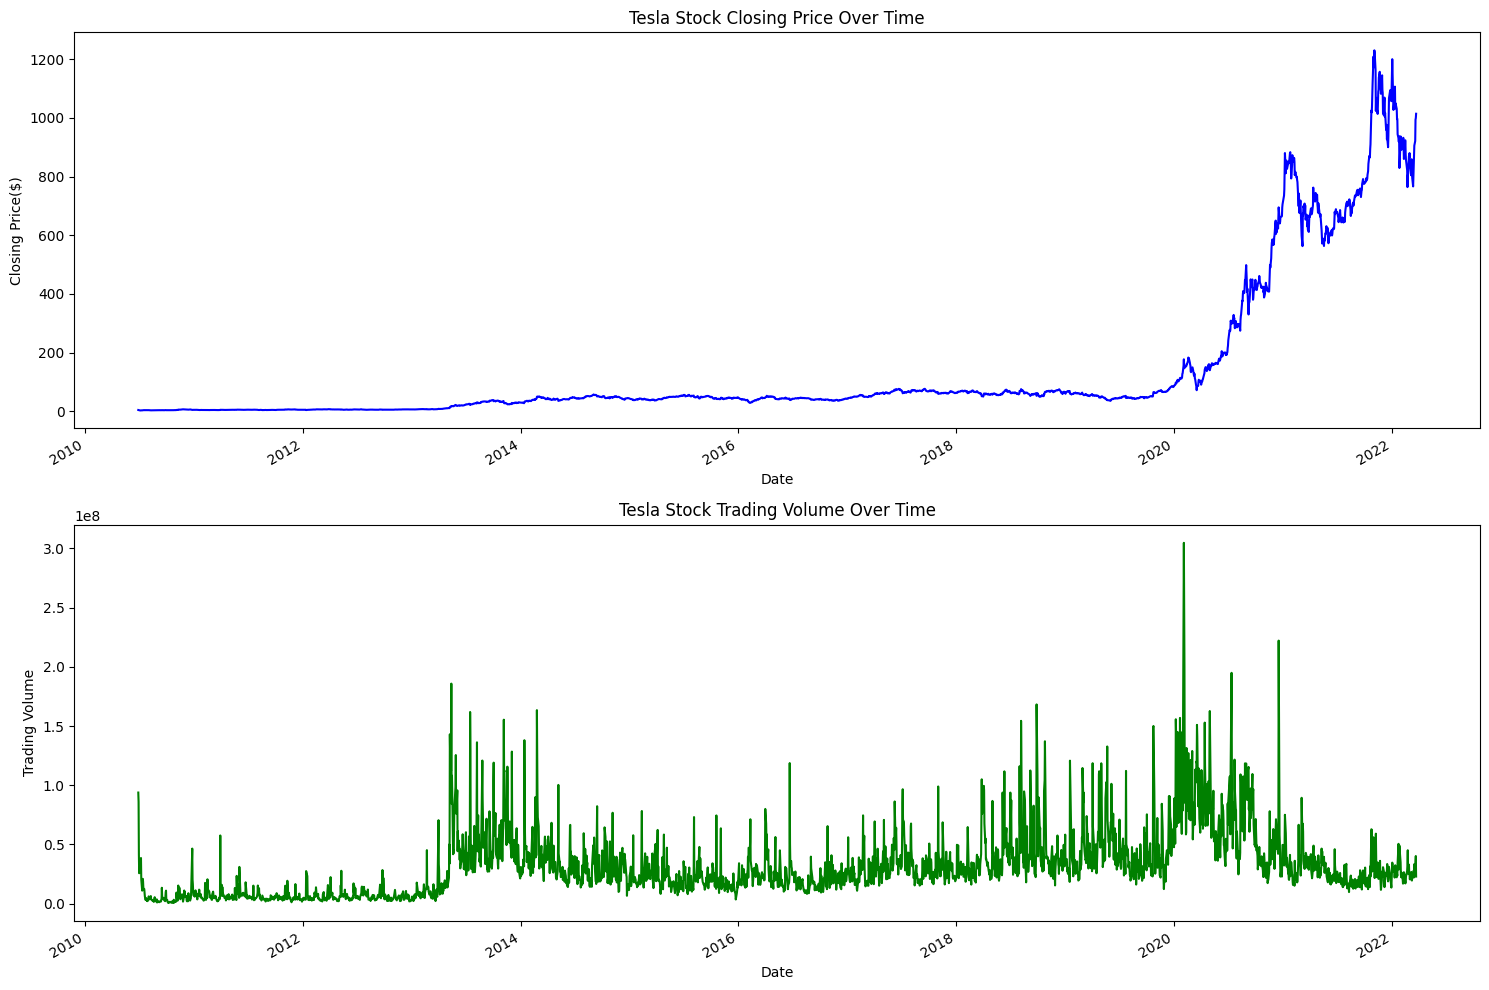

In [38]:
#Convert the "Date" column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

#Set the "Date" column as the index
data.set_index('Date', inplace=True)

#Create a figure and a set of subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

#Plot the closing price over time
data['Close'].plot(ax=axs[0], color='blue')
axs[0].set_title('Tesla Stock Closing Price Over Time')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Closing Price($)')

#Plot the trading volume over time
data['Volume'].plot(ax=axs[1], color='green')
axs[1].set_title('Tesla Stock Trading Volume Over Time')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Trading Volume')

plt.tight_layout()
plt.show()

Tesla Stock Price Analysis:
1. The closing price remained relatively stable until 2019, followed by a sharp surge peaking in 2021.
2. This reflects increased investor confidence, product expansion, and market momentum.


Tesla Trading Volume Trends:
1. Volume spikes around 2013–2014 and again post-2019 indicate heightened investor activity.
2. The 2020 peak aligns with major corporate milestones and broader market interest.

Seasonality Analysis

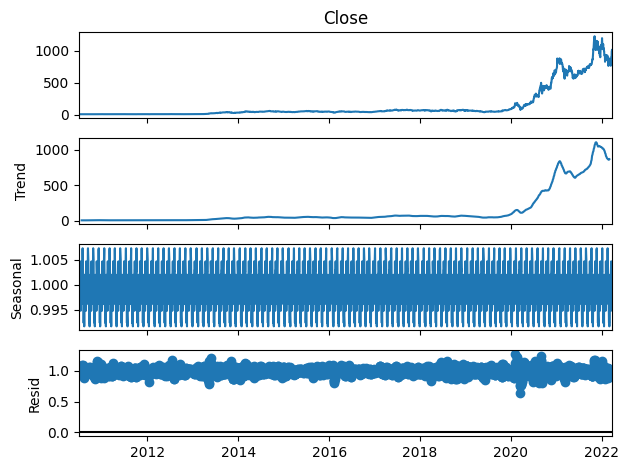

In [39]:
#Seasonality Analysis
from statsmodels.tsa.seasonal import seasonal_decompose

#Perform seasonal decomposition
decomposition = seasonal_decompose(data['Close'], model='multiplicative', period=30)

#Plot the decomposed components
fig = decomposition.plot()
plt.show()

The time series decomposition reveals a strong upward trend in Tesla’s closing price starting around 2017.
The seasonal component remains stable and periodic, suggesting consistent cyclical behavior.



Volatility Analysis

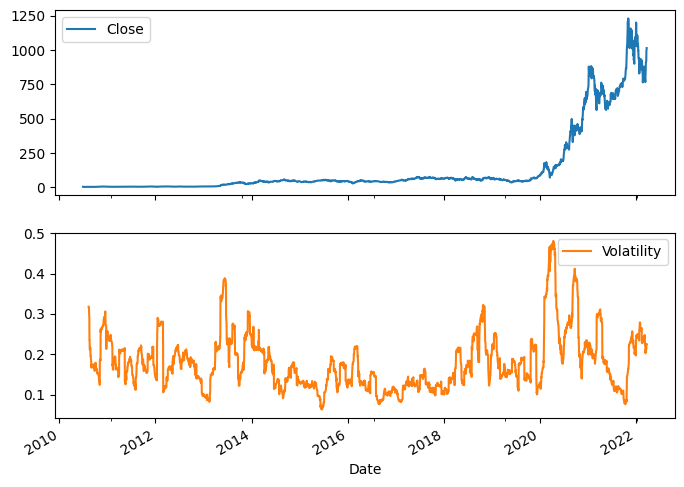

In [40]:
#Volatality Analysis
data['Return'] = data['Close'].pct_change()
data['Volatility'] = data['Return'].rolling(window=30).std()*np.sqrt(30)
data[['Close', 'Volatility']].plot(subplots=True, figsize=(8, 6))
plt.show()

Tesla Volatility Analysis:
1. Volatility remained low and stable until 2013, with sharp spikes observed around 2014, 2020, and 2021.
2. These peaks align with major market events and price surges, indicating periods of heightened investor uncertainty.
3. Overall, volatility tends to rise during rapid price movements, reflecting increased risk and speculative activity.


Moving Average Analysis

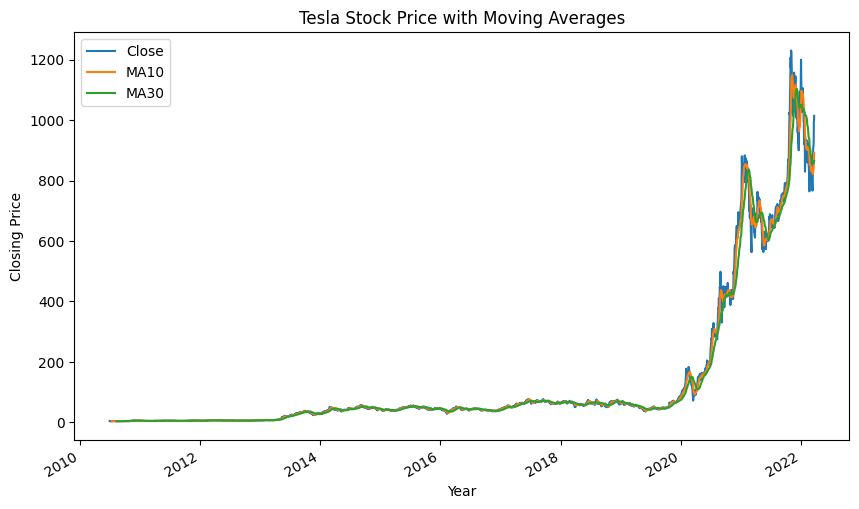

In [43]:
#Moving Average Analysis
data['MA10']= data['Close'].rolling(window=10).mean()
data['MA30']= data['Close'].rolling(window=30).mean()
data[['Close', 'MA10', 'MA30']].plot(figsize=(10, 6))
plt.title('Tesla Stock Price with Moving Averages')
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.show()

The moving average chart smooths Tesla’s closing price to reveal clearer long-term trends.
MA10 (10-day) reacts faster to price changes, closely hugging the actual price line.
MA30 (30-day) lags more, offering a steadier view of overall momentum.
Both averages confirm the sharp rise in Tesla’s stock post-2020, peaking in 2021–2022.
Crossovers between MA10 and MA30 can signal potential trend reversals or entry/exit points.


Return Analysis

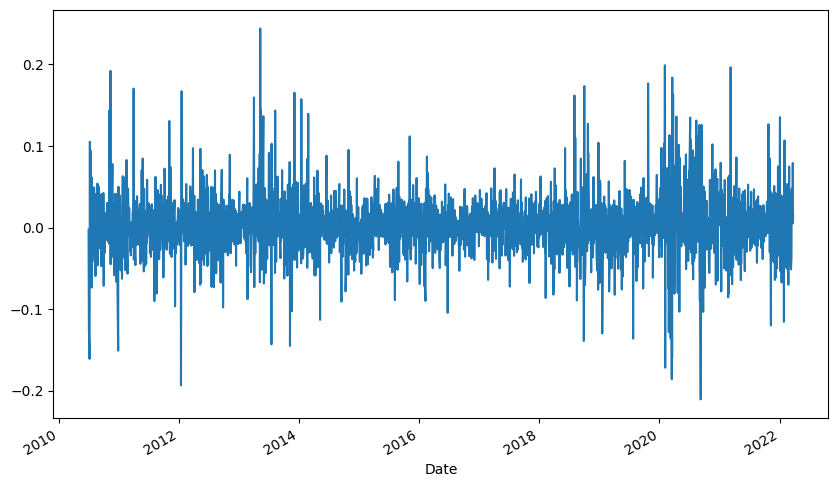

In [46]:
#Return Analysis
data['Return'] = data['Close'].pct_change()
data['Return'].plot(subplots=True, figsize=(10, 6))
plt.show()

1. Returns fluctuate around zero, indicating a mix of gains and losses over time.
2. Noticeable spikes and dips around 2020 suggest periods of high market reaction and volatility.
3. The dense, high-frequency variations reflect short-term trading noise and speculative behavior.
4. Overall, the return series lacks strong seasonality but shows episodic bursts tied to major events.


In [ ]:
#Prepare the data for the Prophet
prophet_df = data.reset_index()[['Date','Close']]
prophet_df.rename(columns = {'Date':'ds','Close':'y'}, inplace = True)

prophet_df.head()

,ds,y
0,2010-06-29,4.778
1,2010-06-30,4.766
2,2010-07-01,4.392
3,2010-07-02,3.840
4,2010-07-06,3.222


In [ ]:
#Initialize the Prophet model
model = Prophet(daily_seasonality=True)


In [ ]:
#Fit the model to the data
model.fit(prophet_df)
#Specify the number of days for predictions
future = model.make_future_dataframe(periods=365)

#Using the model to make predictions
forecast = model.predict(future)

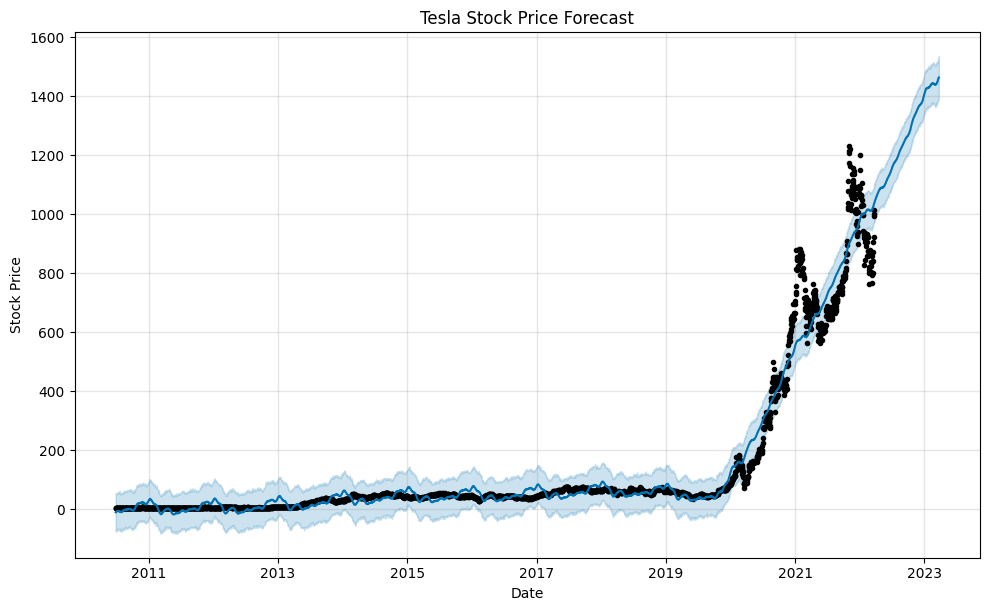

In [ ]:
#Visualize the forecast
model.plot(forecast)
plt.title('Tesla Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.show()

Tesla's stock remained steady from 2010 to 2019, then surged sharply from 2020 to 2022. The forecast shows continued growth but with rising uncertainty, as indicated by the widening confidence interval

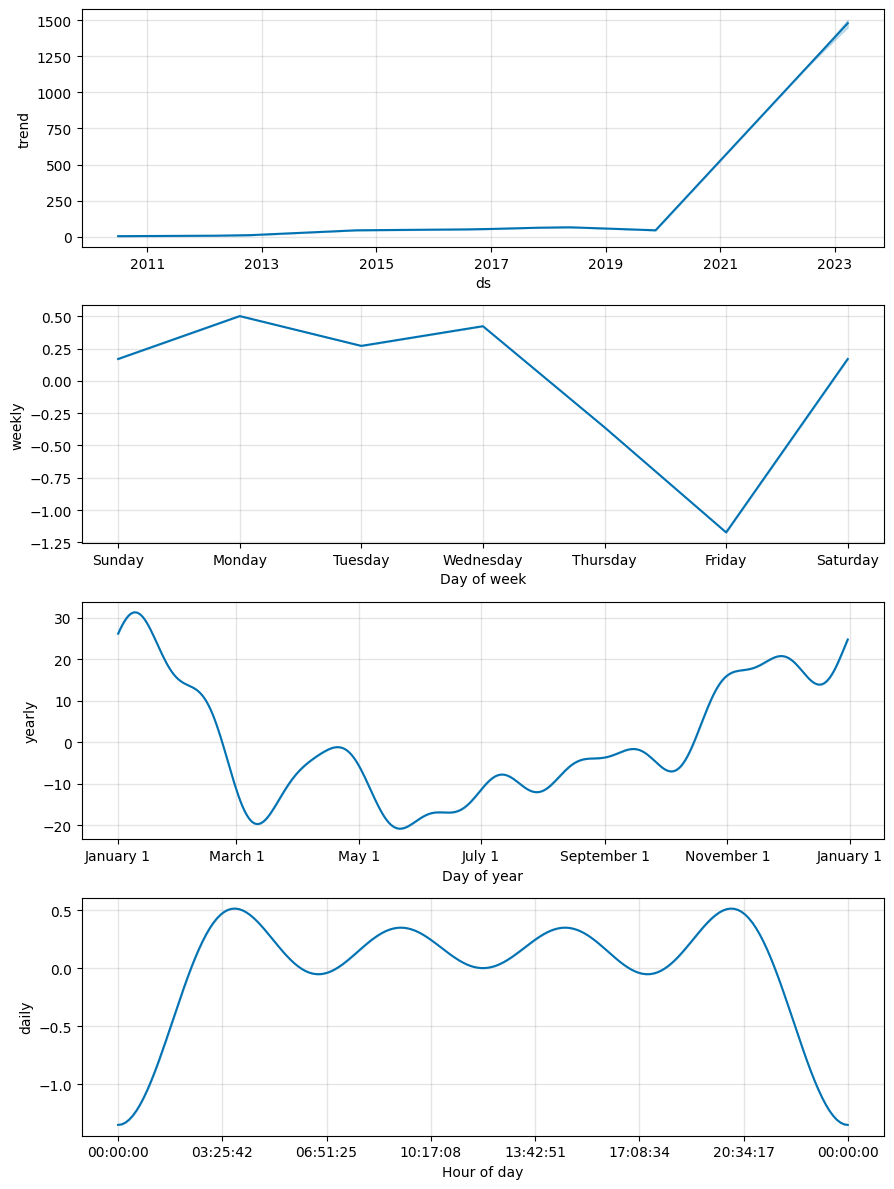

In [ ]:
#Components of the forecast
model.plot_components(forecast)
plt.show()

- Trend (2011–2023): The long-term trend remains flat until 2020, then rises sharply, peaking in 2023 near 1500. This indicates a major upward shift in the underlying value or demand.


- Weekly Seasonality: Activity peaks on Monday and Wednesday, dips lowest on Friday, and partially recovers on Saturday. This suggests stronger engagement or transactions early in the week.


- Yearly Seasonality: Peaks occur around January and November, with troughs in March and May. These patterns may reflect cyclical demand, holidays, or fiscal cycles.


- Daily Seasonality: Multiple peaks and dips throughout the day show intra-day fluctuations, possibly tied to user behavior or market hours.


Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [ ]:
forecast = forecast.drop_duplicates(subset='ds')


In [ ]:
train_forecast = forecast.loc[forecast['ds'].isin(prophet_df['ds'])]

y_true = prophet_df['y'].values
y_pred = train_forecast['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Error & Accuracy Analysis")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")


Error & Accuracy Analysis
MAE: 26.85
RMSE: 49.11
R²: 0.9614
MAPE: 72.42%


- R² = 0.96 -> The model explains about 96% of the variance, indicating high predictive power.


- MAE = 26.85 and RMSE = 49.11 -> Errors are moderate in absolute terms, reflecting some deviations between predicted and actual values.


- MAPE = 72.42% -> The model struggles with scale when prices vary widely.
